# Recurrent Neural Networks (RNN) — From Intuition to Practice

_Generated: 2025-11-12 18:10 UTC_

This Colab notebook is a self-contained, beginner-friendly tour of recurrent neural networks.
We build intuition and math and then implement **SimpleRNN**, **LSTM**, and **GRU** models in TensorFlow/Keras.

**Learning goals:**
1. Understand sequences, hidden state, and unrolling through time.
2. Implement and compare SimpleRNN, LSTM, and GRU on a small text task.
3. Train a character-level model for next-character prediction and sample from it.
4. Inspect training curves and discuss vanishing/exploding gradients and mitigation.


## 0. Environment & Utilities

In [1]:
# If running locally and TensorFlow is not installed, uncomment:
# !pip install -q tensorflow

import os, sys, math, random, json, textwrap, numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


## 1. RNN Intuition & Math

A recurrent neural network processes a sequence one element at a time while maintaining a **hidden state**:
$$
h_t = f(W_{hx} x_t + W_{hh} h_{t-1} + b_h), \quad
y_t = g(W_{yh} h_t + b_y).
$$

- The same weights are **shared** across time steps.
- Training uses **Backpropagation Through Time (BPTT)**; long products of Jacobians can cause **vanishing/exploding gradients**.
- **Gated** variants (LSTM/GRU) add pathways to better preserve or forget information.

We will start with a small **character-level** dataset to keep things transparent.


## 2. Build a Toy Character Dataset

We will create a small corpus from a few sentences and train a next-character predictor.
This keeps training quick and avoids large external downloads while demonstrating core ideas.

In [2]:
corpus = (
    "To learn any skill, you start with small, graspable pieces and practice consistently. "
    "Neural networks do the same: they break big problems into small, trainable steps over time. "
    "Recurrent neural networks maintain a hidden state that carries information forward to the next step. "
    "With enough data and careful tuning, they can model remarkable temporal patterns."
)

# Lowercase for simplicity
text = corpus.lower()
vocab = sorted(set(text))
vocab_size = len(vocab)
stoi = {ch:i for i,ch in enumerate(vocab)}
itos = {i:ch for ch,i in stoi.items()}

print('Corpus length:', len(text))
print('Vocab size:', vocab_size)
print('Sample vocab:', ''.join(vocab[:80]))

Corpus length: 360
Vocab size: 27
Sample vocab:  ,.:abcdefghiklmnoprstuvwxy


### 2.1 Vectorize into Input/Target Sequences
We prepare sequences of length `seq_len`. For each window, the target is the **next character**.

In [3]:
seq_len = 60
step = 1

inputs = []
targets = []
for i in range(0, len(text) - seq_len, step):
    chunk = text[i:i+seq_len]
    nxt = text[i+seq_len]
    inputs.append([stoi[c] for c in chunk])
    targets.append(stoi[nxt])

inputs = np.array(inputs, dtype=np.int32)
targets = np.array(targets, dtype=np.int32)

print('Num sequences:', inputs.shape[0], 'Sequence length:', seq_len)

Num sequences: 300 Sequence length: 60


### 2.2 One-Hot Encode Inputs (Char-Level)
For clarity, we will one-hot encode characters. (An embedding layer is also fine.)

In [4]:
def to_onehot(x, num_classes):
    # x: (batch, seq_len) int32
    b, s = x.shape
    eye = np.eye(num_classes, dtype=np.float32)
    out = eye[x]  # (batch, seq_len, num_classes)
    return out

X = to_onehot(inputs, vocab_size)
y = tf.keras.utils.to_categorical(targets, num_classes=vocab_size)

print('X shape:', X.shape, 'y shape:', y.shape)

X shape: (300, 60, 27) y shape: (300, 27)


### 2.3 Train/Validation Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)
print('Train:', X_train.shape, 'Val:', X_val.shape)

Train: (255, 60, 27) Val: (45, 60, 27)


## 3. Utility: Plot Training Curves

In [6]:
def plot_history(hist, title='Training history'):
    plt.figure()
    plt.plot(hist.history['loss'], label='loss')
    if 'val_loss' in hist.history:
        plt.plot(hist.history['val_loss'], label='val_loss')
    if 'accuracy' in hist.history:
        plt.plot(hist.history['accuracy'], label='accuracy')
    if 'val_accuracy' in hist.history:
        plt.plot(hist.history['val_accuracy'], label='val_accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Metric')
    plt.title(title)
    plt.legend()
    plt.show()

## 4. SimpleRNN Model
We begin with a single **SimpleRNN** layer followed by a Dense softmax for next-character prediction.

In [7]:
tf.keras.backend.clear_session()

model_rnn = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2])),
    layers.SimpleRNN(128),
    layers.Dense(vocab_size, activation='softmax')
])

model_rnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,451 (91.61 KB)

 Trainable params: 23,451 (91.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.0663 - loss: 3.2605 - val_accuracy: 0.0667 - val_loss: 3.2124
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1810 - loss: 2.9950 - val_accuracy: 0.0667 - val_loss: 3.0832
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2326 - loss: 2.8475 - val_accuracy: 0.0889 - val_loss: 3.0366
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2832 - loss: 2.7080 - val_accuracy: 0.1333 - val_loss: 3.0013
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3286 - loss: 2.5844 - val_accuracy: 0.1333 - val_loss: 3.0071
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3704 - loss: 2.4671 - val_accuracy: 0.1333 - val_loss: 2.9845
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3709 - loss: 2.3586 - val_accuracy: 0.0889 - val_loss: 2.9904
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4246 - loss: 2.2402 - val_accuracy: 0.0889 - val_loss: 2.9759

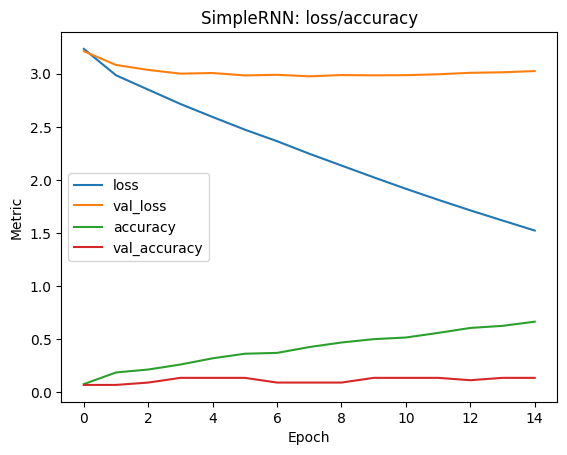

In [8]:
hist_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64, epochs=15, verbose=1
)

plot_history(hist_rnn, title='SimpleRNN: loss/accuracy')

### 4.1 Sampling (Text Generation)
Given a seed text, we repeatedly predict the next character and append it.

In [9]:
def sample(model, seed, gen_len=200, temperature=1.0):
    assert len(seed) >= 1
    s = seed[-seq_len:]
    out = s
    for _ in range(gen_len):
        # Vectorize latest seq_len chars (pad left if needed)
        pad = max(0, seq_len - len(s))
        window = (' ' * pad + s)[-seq_len:]
        x = np.array([[stoi.get(c, 0) for c in window]], dtype=np.int32)
        x = to_onehot(x, vocab_size)
        preds = model.predict(x, verbose=0)[0]
        # temperature sampling
        preds = np.log(preds + 1e-9) / temperature
        preds = np.exp(preds) / np.sum(np.exp(preds))
        idx = np.random.choice(len(preds), p=preds)
        out += itos[idx]
        s += itos[idx]
        s = s[-seq_len:]
    return out

seed = 'neural networks '
print(sample(model_rnn, seed, gen_len=200, temperature=0.8))

neural networks nvite  thi vhed hee raa  egoe e  twin mlbe teinkl.vltthu m ai scge p ypa rrmp eettla ,mmsc rtsth n a k nteereaaeistrienatte nios abd kuekglwu ne bgl hrca y nt:s rmm secafp efta ntcedrrmtmfoectrmc sotr


## 5. LSTM Model
Replace the recurrent cell with **LSTM** to better capture longer-range dependencies.

In [10]:
tf.keras.backend.clear_session()

model_lstm = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2])),
    layers.LSTM(128),
    layers.Dense(vocab_size, activation='softmax')
])
model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        79,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,355 (325.61 KB)

 Trainable params: 83,355 (325.61 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 343ms/step - accuracy: 0.0610 - loss: 3.2831 - val_accuracy: 0.0667 - val_loss: 3.2499
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.1727 - loss: 3.2242 - val_accuracy: 0.1333 - val_loss: 3.1356
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.1492 - loss: 3.0500 - val_accuracy: 0.1333 - val_loss: 2.9982
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.1492 - loss: 2.9626 - val_accuracy: 0.1333 - val_loss: 2.9268
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.1492 - loss: 2.9073 - val_accuracy: 0.1333 - val_loss: 2.9003
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.1492 - loss: 2.8959 - val_accuracy: 0.1333 - val_loss: 2.9076
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.1492 - loss: 2.8969 - val_accuracy: 0.1333 - val_loss: 2.9103
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.1492 - loss: 2.8900 - val_accuracy: 0.1333 - val_loss:

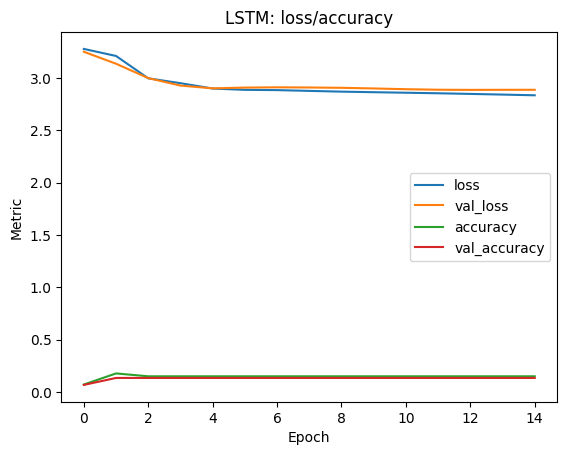

In [11]:
hist_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64, epochs=15, verbose=1
)

plot_history(hist_lstm, title='LSTM: loss/accuracy')

In [12]:
seed = 'recurrent models '
print(sample(model_lstm, seed, gen_len=200, temperature=0.8))

recurrent models n  tm  o alonaoadpnsnl eaauetnrhih oa n ttte teutsaesa ltnl nw itoooearrstiirnnrtde l hial  re kran  linouicrae  troe  alonatplmeaer    soi ih eenn enisn  n mtleneitett     o es rb ontpra,rrweeretserr


## 6. GRU Model
A **GRU** is a lighter-weight gated RNN and often trains faster with similar accuracy.

In [13]:
tf.keras.backend.clear_session()

model_gru = models.Sequential([
    layers.Input(shape=(X.shape[1], X.shape[2])),
    layers.GRU(128),
    layers.Dense(vocab_size, activation='softmax')
])
model_gru.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        60,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,771 (249.11 KB)

 Trainable params: 63,771 (249.11 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 261ms/step - accuracy: 0.0464 - loss: 3.2970 - val_accuracy: 0.0667 - val_loss: 3.2813
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.1059 - loss: 3.2537 - val_accuracy: 0.0444 - val_loss: 3.2479
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.1409 - loss: 3.2100 - val_accuracy: 0.0889 - val_loss: 3.2040
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.1476 - loss: 3.1526 - val_accuracy: 0.1333 - val_loss: 3.1314
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.1534 - loss: 3.0567 - val_accuracy: 0.1333 - val_loss: 2.9789
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.1492 - loss: 2.9227 - val_accuracy: 0.1333 - val_loss: 2.9391
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.1492 - loss: 2.8669 - val_accuracy: 0.1333 - val_loss: 2.9331
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.1534 - loss: 2.8577 - val_accuracy: 0.1333 - val_loss:

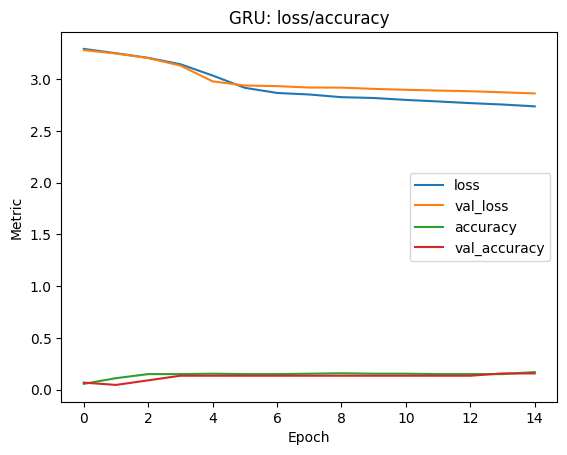

In [14]:
hist_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64, epochs=15, verbose=1
)

plot_history(hist_gru, title='GRU: loss/accuracy')

In [15]:
seed = 'sequence learning '
print(sample(model_gru, seed, gen_len=200, temperature=0.8))

sequence learning  tirdte t ettkmeacnrrr i mete  rn  r so  veertwpe slet l i  ,nrlteas t t tix muinnenlt cttena iel uvplarn trtonets  erw neursgea tryyeptsah tmanlc olrisilse  rnoa  emeetdgrentt thaeuhana  : .naetgn a 


## 7. Compare Models
We collect final validation accuracy from each model for a quick comparison.

In [16]:
def last_val_acc(hist):
    return float(hist.history['val_accuracy'][-1]) if 'val_accuracy' in hist.history else float('nan')

summary = {
    'SimpleRNN_val_acc': last_val_acc(hist_rnn),
    'LSTM_val_acc': last_val_acc(hist_lstm),
    'GRU_val_acc': last_val_acc(hist_gru)
}
print(json.dumps(summary, indent=2))

{
  "SimpleRNN_val_acc": 0.13333334028720856,
  "LSTM_val_acc": 0.13333334028720856,
  "GRU_val_acc": 0.15555556118488312
}


## 8. Notes on Stability & Tips

- **Exploding gradients:** try gradient clipping (`clipnorm`/`clipvalue` in optimizers) or reduce learning rate.

- **Vanishing gradients:** LSTMs/GRUs help; also consider residual connections or attention mechanisms.

- **Regularization:** Dropout on recurrent layers (`recurrent_dropout`) and on inputs can help generalization.

- **Batching:** For variable-length sequences, use padding and masks, or ragged sequences.

- **Initialization:** Orthogonal initialization for recurrent kernels often stabilizes training.



## 9. (Bonus) Using an Embedding Instead of One-Hot
This cell shows how to rewire the input to use a trainable **Embedding** layer.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 32)         │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         3,483 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,779 (338.98 KB)

 Trainable params: 86,779 (338.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 528ms/step - accuracy: 0.0449 - loss: 3.2924 - val_accuracy: 0.1556 - val_loss: 3.2776
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.1492 - loss: 3.2676 - val_accuracy: 0.1333 - val_loss: 3.2340
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.1492 - loss: 3.1837 - val_accuracy: 0.1333 - val_loss: 3.0166
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.1492 - loss: 2.9935 - val_accuracy: 0.1333 - val_loss: 3.0200
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.1492 - loss: 2.9221 - val_accuracy: 0.1333 - val_loss: 2.9629
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - accuracy: 0.1492 - loss: 2.9171 - val_accuracy: 0.1333 - val_loss: 2.9552
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.1492 - loss: 2.9242 - val_accuracy: 0.1333 - val_loss: 2.9364
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.1492 - loss: 2.9149 - val_accuracy: 0.1333 - val_loss:

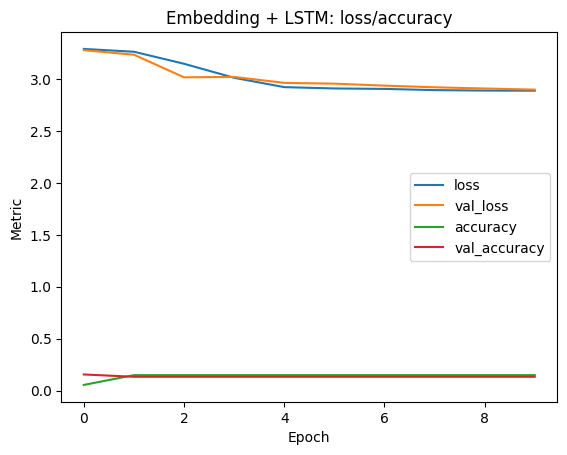

In [17]:
# Rebuild integer inputs for embedding example
X_ids = inputs  # (num_samples, seq_len)
y_ids = np.argmax(y, axis=1)  # int targets

X_train_ids, X_val_ids, y_train_ids, y_val_ids = train_test_split(X_ids, y_ids, test_size=0.15, random_state=42)

embed_dim = 32

model_embed_lstm = models.Sequential([
    layers.Input(shape=(seq_len,)),
    layers.Embedding(input_dim=vocab_size, output_dim=embed_dim),
    layers.LSTM(128),
    layers.Dense(vocab_size, activation='softmax')
])

model_embed_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_embed_lstm.summary()

hist_embed = model_embed_lstm.fit(
    X_train_ids, y_train_ids,
    validation_data=(X_val_ids, y_val_ids),
    batch_size=64, epochs=10, verbose=1
)

plot_history(hist_embed, title='Embedding + LSTM: loss/accuracy')